In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
import matplotlib as mpl
from tqdm import tqdm
from scipy.stats.mstats import ttest_onesamp
from scipy.optimize import curve_fit


#mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use(['science','notebook'])


CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=CB_color_cycle)

plt.rcParams['font.size'] = 18
plt.rcParams['legend.fontsize'] = 14

In [3]:
### DATA argregation

nametemplate = "IDS/dipoles_1stshell_t0_id"
res = np.zeros((100,3))
res[:,0] = np.arange(1,101)
for i in range(1,101):
    data = np.loadtxt(f"{nametemplate}_E{i}.txt")
    res[i-1,1] = np.mean(data[:,0])
    res[i-1,2] = np.std(data[:,0])/np.sqrt(50) * 3
    
np.savetxt(f"{nametemplate}_All.txt", res)

/tmp/ipykernel_77842/2685639869.py:12: RuntimeWarning: invalid value encountered in sqrt
  return b*np.sqrt(a*x)/(1+np.sqrt(a*x))
/tmp/ipykernel_77842/2685639869.py:23: RuntimeWarning: invalid value encountered in log
  return b*np.log(1+a*x)/(1+np.log(1+a*x))


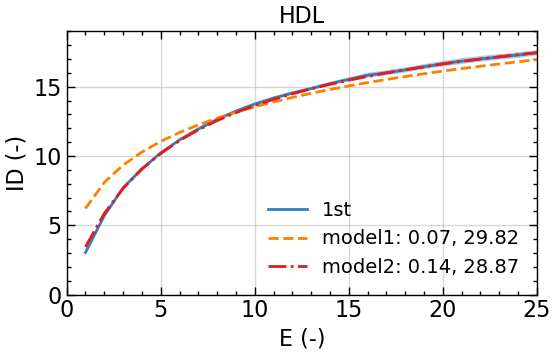

In [4]:
fig, ax = plt.subplots()

ax.set_xlabel("E (-)")
ax.set_ylabel("ID (-)")

ax.plot(res[:,0], res[:,1], label = "1st", ls = "-" , color = CB_color_cycle[0])
ax.fill_between(res[:,0], res[:,1]-res[:,2], res[:,1]+res[:,2], color = CB_color_cycle[0], alpha=0.4, lw=0)

X = res[:,0]
Y = res[:,1]
def model1(x,a,b):
    return b*np.sqrt(a*x)/(1+np.sqrt(a*x))
    #return b*np.log(1+a*x)/(1+np.log(1+a*x))

(A1,B1), pcov = curve_fit(model1, X ,Y, p0=(1,1))

Yres = model1(X,A1,B1)

ax.plot(X, Yres, label = f"model1: {A1:.2f}, {B1:.2f}", ls = "--" , color = CB_color_cycle[1])

def model2(x,a,b):
    #return b*np.sqrt(a*x)/(1+np.sqrt(a*x))
    return b*np.log(1+a*x)/(1+np.log(1+a*x))

(A2,B2), pcov = curve_fit(model2, X ,Y, p0=(1,1))

Yres = model2(X,A2,B2)

ax.plot(X, Yres, label = f"model2: {A2:.2f}, {B2:.2f}", ls = "-." , color = CB_color_cycle[7])

ax.set_xlim([0,25])
ax.set_ylim([0,19])

ax.legend()
ax.grid(alpha=0.5)
ax.set_title("HDL")
fig.set_size_inches((6,4))
plt.tight_layout()
plt.savefig("IDS_HDL.png", dpi=300)
plt.savefig("IDS_HDL.pdf", dpi=300)
plt.show()


In [5]:
print(Y[12])

14.87406714559049


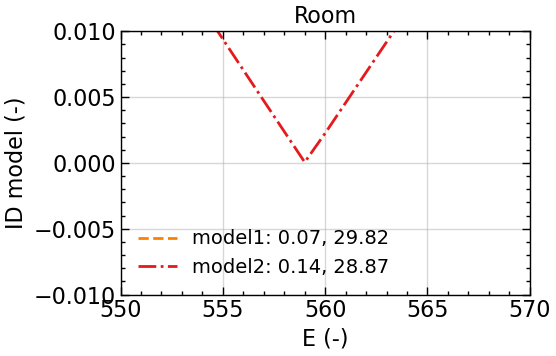

In [10]:
fig, ax = plt.subplots()

ax.set_ylim((-0.01,0.01))
ax.set_xlim((550,570))

X = np.arange(2000)
ax.set_xlabel("E (-)")
ax.set_ylabel("ID model (-)")

Yres = np.abs(model1(X,A1,B1) - 0.9*B1)

ax.plot(X, Yres, label = f"model1: {A1:.2f}, {B1:.2f}", ls = "--" , color = CB_color_cycle[1])

Yres = np.abs(model1(X,A2,B2) - 0.9*B2)

ax.plot(X, Yres, label = f"model2: {A2:.2f}, {B2:.2f}", ls = "-." , color = CB_color_cycle[7])

ax.legend()
ax.grid(alpha=0.5)
ax.set_title("Room")
fig.set_size_inches((6,4))
plt.tight_layout()
plt.savefig("IDS_Room.png", dpi=300)
plt.savefig("IDS_Room.pdf", dpi=300)
plt.show()